In [69]:
using Distributions, Plots, Roots
tn01(μ,σ) = truncated(Normal(μ,σ),0,1)
max_std = 1/√12 #from uniform 

0.2886751345948129

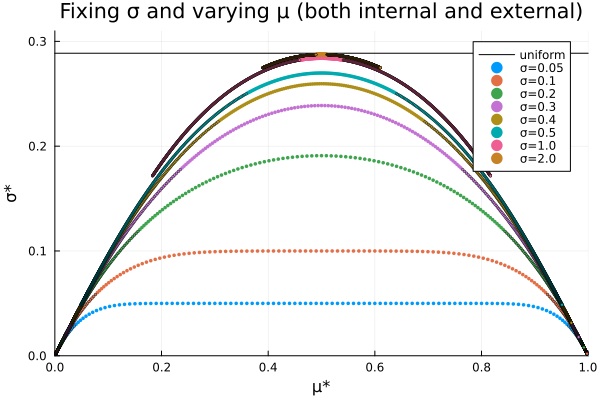

In [3]:
plt = plot([0,1], max_std*ones(2), 
            xlabel = "μ*", ylabel = "σ*",
            xlim = (0,1), ylim=(0,0.31), 
            c=:black, label="uniform",
            title = "Fixing σ and varying μ (both internal and external)")

for (i,σ) ∈ enumerate([0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 2.0])
    μ_range = 0:0.01:1
    means = [mean(tn01(μ, σ)) for μ ∈ μ_range]
    stds = [std(tn01(μ, σ)) for μ ∈ μ_range]
    scatter!(plt, means, stds, ms=2.0, msw=0.0, c=i, label="σ=$σ")

    μ_range = -5:0.01:-0.01
    means = [mean(tn01(μ, σ)) for μ ∈ μ_range]
    stds = [std(tn01(μ, σ)) for μ ∈ μ_range]
    scatter!(plt, means, stds, ms=1.5, msw=0.5, c=i, label=false)

    μ_range = 1.01:0.01:6
    means = [mean(tn01(μ, σ)) for μ ∈ μ_range]
    stds = [std(tn01(μ, σ)) for μ ∈ μ_range]
    scatter!(plt, means, stds, ms=1.5, msw=0.5, c=i, label=false)
end
plt

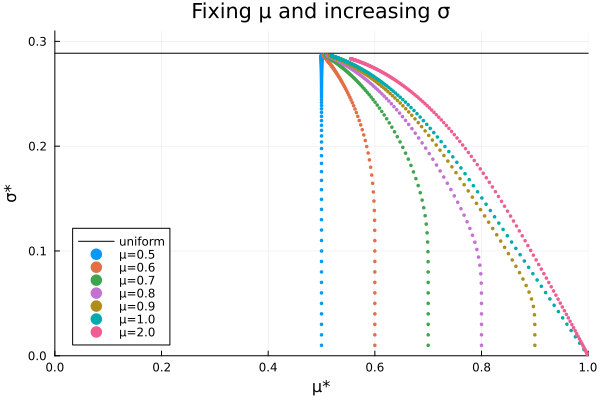

In [4]:
plt = plot([0,1], max_std*ones(2), 
        xlim = (0,1), ylim=(0,0.31), 
        xlabel = "μ*", ylabel = "σ*",
        c=:black, label="uniform",
        title = "Fixing μ and increasing σ")

for (i,μ) ∈ enumerate(union(0.5:0.1:1.0, 2.0))
    σ_range = 0.01:0.01:1.5
    means = [mean(tn01(μ, σ)) for σ ∈ σ_range]
    stds = [std(tn01(μ, σ)) for σ ∈ σ_range]
    scatter!(plt, means, stds, ms=2.0, msw=0.0, c=i, label="μ=$μ")
end
plt

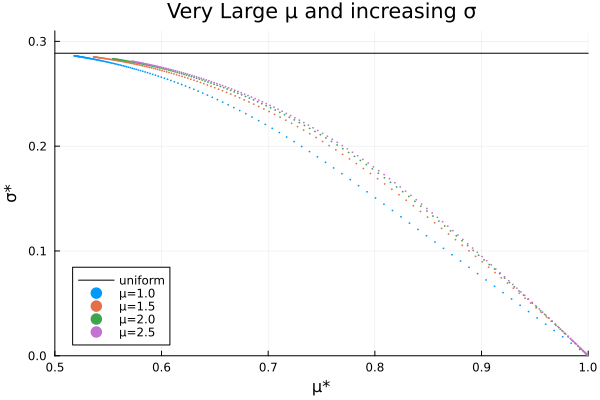

In [5]:
plt = plot([0,1], max_std*ones(2), 
        xlim = (0.5,1), ylim=(0,0.31), 
        xlabel = "μ*", ylabel = "σ*",
        c=:black, label="uniform",
        title = "Very Large μ and increasing σ")

for (i,μ) ∈ enumerate(1.0:0.5:2.5)
    σ_range = 0.01:0.01:1.5
    means = [mean(tn01(μ, σ)) for σ ∈ σ_range]
    stds = [std(tn01(μ, σ)) for σ ∈ σ_range]
    scatter!(plt, means, stds, ms=1.0, msw=0.0, c=i, label="μ=$μ")
end
plt

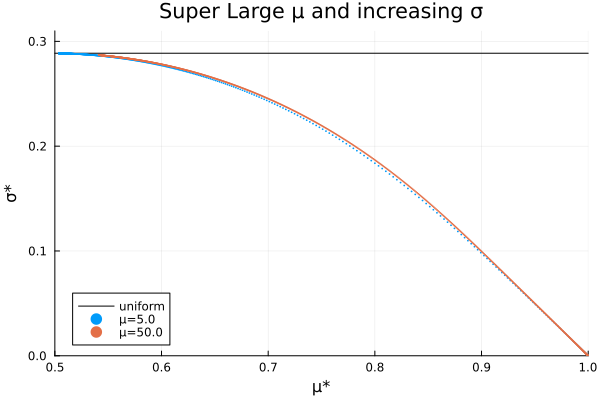

In [6]:
plt = plot([0,1], max_std*ones(2), 
        xlim = (0.5,1), ylim=(0,0.31), 
        xlabel = "μ*", ylabel = "σ*",
        c=:black, label="uniform",
        title = "Super Large μ and increasing σ")

for (i,μ) ∈ enumerate([5.0,50.0])
    σ_range = 0.01:0.01:10.0
    means = [mean(tn01(μ, σ)) for σ ∈ σ_range]
    stds = [std(tn01(μ, σ)) for σ ∈ σ_range]
    scatter!(plt, means, stds, ms=1.0, msw=0.0, c=i, label="μ=$μ")
end
plt

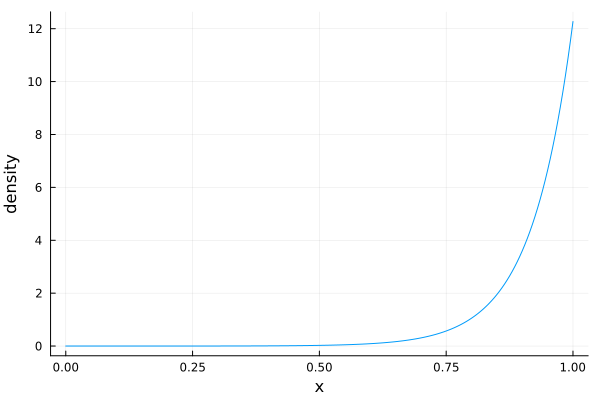

In [12]:
# Plot the truncated with high mu and we see it is the "tail" of the normal (renormalized)... if too high numerical problems
x_range = 0:0.005:1
plot(x_range, pdf.(tn01(50.0,2.0), x_range), label=false, xlabel="x", ylabel="density")

In [34]:
# https://chat.accumulationpoint.com/c/6ff73175-9f3a-4acd-8039-be1d88678fea

In [16]:
f_tr_asymptotic(x; μ= 100.0, σ = 5.0) = (μ/σ^2) * exp((μ/σ^2)*x)/(exp(μ/σ^2)-1)

f_tr_asymptotic (generic function with 1 method)

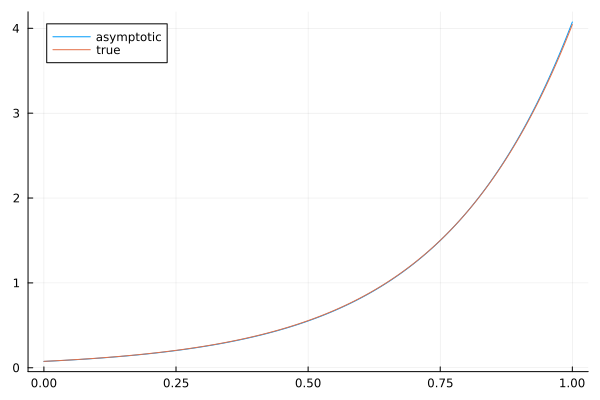

In [17]:
plot(x_range, f_tr_asymptotic.(x_range), label="asymptotic")
plot!(x_range, pdf.(tn01(100.0,5.0), x_range), label="true")

In [18]:
mean_trunc_exp(μ, σ) = (exp(μ/σ^2)*((μ/σ^2) - 1) + 1) / ((μ/σ^2)*(exp(μ/σ^2) - 1))

mean_trunc_exp (generic function with 1 method)

In [19]:
mean_trunc_exp(100, 5.0)

0.7686573603637741

In [20]:
mean(tn01(100.0,5.0))

0.7675483924193429

In [21]:
var_trunc_exp(μ,σ) = (exp(μ/σ^2)*(1-2/(μ/σ^2)+2/(μ/σ^2)^2)/(exp(μ/σ^2)-1) - 2/((exp(μ/σ^2)-1)*(μ/σ^2)^2)) -
                      ((exp(μ/σ^2)*((μ/σ^2)-1)+1)/((μ/σ^2)*(exp(μ/σ^2)-1)))^2

var_trunc_exp (generic function with 1 method)

In [22]:
√var_trunc_exp(100,5.0)

0.20855345247797324

In [23]:
std(tn01(100.0,5.0))

0.20911299239522052

$$
\mathbb{E}[X] = 
\frac{
    e^{\frac{\mu}{\sigma^2}} \left( \frac{\mu}{\sigma^2} - 1 \right) + 1
}{
    \frac{\mu}{\sigma^2} \left( e^{\frac{\mu}{\sigma^2}} - 1 \right)
}
$$
$$
\operatorname{Var}[X] =
\frac{
    e^{\frac{\mu}{\sigma^2}} \left(1 - \frac{2\sigma^2}{\mu} + \frac{2\sigma^4}{\mu^2} \right) - \frac{2\sigma^4}{\mu^2}
}{
    e^{\frac{\mu}{\sigma^2}} - 1
}
- \left( \frac{
    e^{\frac{\mu}{\sigma^2}} \left( \frac{\mu}{\sigma^2} - 1 \right) + 1
}{
    \frac{\mu}{\sigma^2} \left( e^{\frac{\mu}{\sigma^2}} - 1 \right)
} \right)^2
$$

$$
\mu^* = \frac{e^{\lambda}(\lambda - 1) + 1}{\lambda \left(e^{\lambda} - 1\right)}
$$

Then you "solve it" numerically - or maybe we have special function form (maybe not) - to find $\lambda$.

$$
\text{maximal}~\sigma^* =
\frac{
    e^{\lambda} \left(1 - \frac{2}{\lambda} + \frac{2}{\lambda^2}\right) - \frac{2}{\lambda^2}
}{
    e^{\lambda} - 1
}
-
\left(
    \frac{e^{\lambda}(\lambda - 1) + 1}{\lambda \left( e^{\lambda} - 1 \right )}
\right)^2
$$

In [25]:
function solve_lambda_from_mean(μstar; λ_guess=1.0)
    f(λ) = (exp(λ)*(λ-1) + 1)/(λ*(exp(λ)-1)) - μstar
    # λ ∈ (0, ∞); reasonable upper bound for most purposes
    find_zero(f, λ_guess; order=8)
end

solve_lambda_from_mean (generic function with 1 method)

In [27]:
λ = solve_lambda_from_mean(0.7)

2.672103855273385

In [28]:
var_trunc_exp(λ) = (exp(λ)*(1 - 2/λ + 2/λ^2) - 2/λ^2)/(exp(λ) - 1) - ((exp(λ)*(λ - 1) + 1)/(λ*(exp(λ) - 1)))^2

var_trunc_exp (generic function with 2 methods)

In [29]:
√var_trunc_exp(λ)

0.24557121071710555

In [41]:
sigmas = Float64[]
mus = 0.5:0.01:0.99
for μ in mus
    λ = solve_lambda_from_mean(μ)
    σ = √var_trunc_exp(λ)
    push!(sigmas, σ)
end;

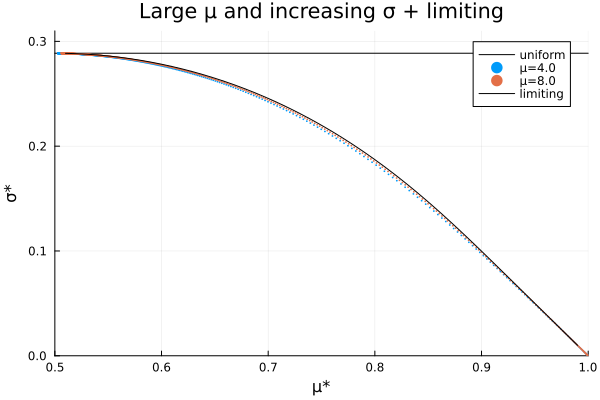

In [42]:
plt = plot([0,1], max_std*ones(2), 
        xlim = (0.5,1), ylim=(0,0.31), 
        xlabel = "μ*", ylabel = "σ*",
        c=:black, label="uniform",
        title = "Large μ and increasing σ + limiting")

for (i,μ) ∈ enumerate([4.0,8.0])
    σ_range = 0.01:0.01:10.0
    means = [mean(tn01(μ, σ)) for σ ∈ σ_range]
    stds = [std(tn01(μ, σ)) for σ ∈ σ_range]
    scatter!(plt, means, stds, ms=1.0, msw=0.0, c=i, label="μ=$μ")
end
plot!(plt, mus, sigmas, c=:black, label = "limiting")
plt

In [44]:
std(truncated(Normal(2.3,0.5),0,1))

0.14424464150517405

## Checking

In [126]:
function bb(μ_star)
    f(λ) = (1 - (1 + λ) * exp(-λ)) / (λ * (1 - exp(-λ))) - μ_star
    var_truncexp(λ) = (2 - (λ^2 + 2λ + 2) * exp(-λ)) / (λ^2 * (1 - exp(-λ))) - ((1 - (1 + λ) * exp(-λ)) / (λ * (1 - exp(-λ))))^2
    λ_found = find_zero(f, 0.5; order=8)
    return var_truncexp(λ_found)
end;

$$
-\lambda = \frac{\mu}{\sigma^2}
$$

$$
\sigma = \sqrt{\frac{\mu}{-\lambda}}
$$

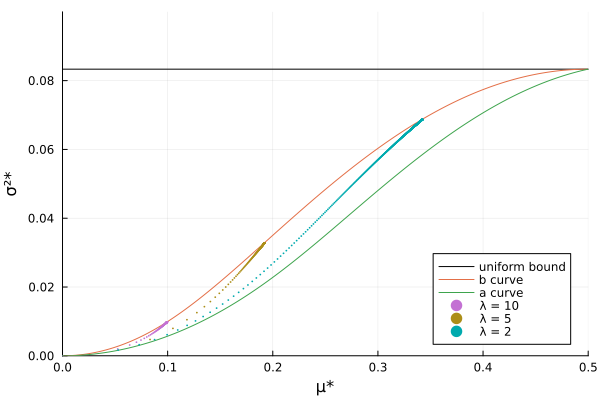

In [127]:
plot([0,1], (1/12)*ones(2), 
            xlabel = "μ*", ylabel = "σ²*",
            xlim = (0,0.5), ylim=(0,0.1), 
            c=:black, label="uniform bound")

x_range = 0:0.001:0.499
bb_vals = [bb(x) for x in x_range]
plot!(x_range, bb_vals, label = "b curve")

σ_range = 0.001:0.001:10
a_curve_x = [mean(tn01(0,σ)) for σ in σ_range]
a_curve_y = [var(tn01(0,σ)) for σ in σ_range]
plot!(a_curve_x, a_curve_y, label="a curve")

μ_range = -50:0.1:0
λ = 10
means = [mean(tn01(μ, sqrt(μ/-λ))) for μ ∈ μ_range]
vars = [var(tn01(μ, sqrt(μ/-λ))) for μ ∈ μ_range]
scatter!(means, vars, ms=1.0, msw=0.0, label="λ = 10")

μ_range = -50:0.1:0
λ = 5
means = [mean(tn01(μ, sqrt(μ/-λ))) for μ ∈ μ_range]
vars = [var(tn01(μ, sqrt(μ/-λ))) for μ ∈ μ_range]
scatter!(means, vars, ms=1.0, msw=0.0, label="λ = 5")

μ_range = -50:0.01:0
λ = 2
means = [mean(tn01(μ, sqrt(μ/-λ))) for μ ∈ μ_range]
vars = [var(tn01(μ, sqrt(μ/-λ))) for μ ∈ μ_range]
scatter!(means, vars, ms=1.0, msw=0.0, label="λ = 2")